In [1]:
import pandas as pd

In [6]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.shape

(9994, 21)

In [10]:
df.to_csv("superstore_clean.csv", index=False)

In [11]:
df['Sales'].sum()

np.float64(2297200.8603000003)

In [12]:
df['Profit'].sum()

np.float64(286397.0217)

In [13]:
df['Order ID'].nunique()

5009

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [18]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Month_Year'] = df['Order Date'].dt.to_period('M')

In [19]:
df[['Order Date','Year','Month','Month_Name','Month_Year']].head()

,Order Date,Year,Month,Month_Name,Month_Year
0,2016-11-08,2016,11,November,2016-11
1,2016-11-08,2016,11,November,2016-11
2,2016-06-12,2016,6,June,2016-06
3,2015-10-11,2015,10,October,2015-10
4,2015-10-11,2015,10,October,2015-10


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df['Sales'].sum()

np.float64(2297200.8603000003)

In [22]:
df['Profit'].sum()

np.float64(286397.0217)

In [23]:
df['Order ID'].nunique()

5009

In [24]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales.head()

,Month_Year,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


In [25]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values(by='Sales', ascending=False)
category_sales

,Category,Sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


In [26]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values(by='Sales', ascending=False)
region_sales

,Region,Sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


In [27]:
top_products = df.groupby('Product Name')['Sales'].sum().reset_index()
top_products = top_products.sort_values(by='Sales', ascending=False).head(10)
top_products

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


In [28]:
monthly_sales.to_csv("monthly_sales.csv", index=False)
category_sales.to_csv("category_sales.csv", index=False)
region_sales.to_csv("region_sales.csv", index=False)
top_products.to_csv("top_products.csv", index=False)

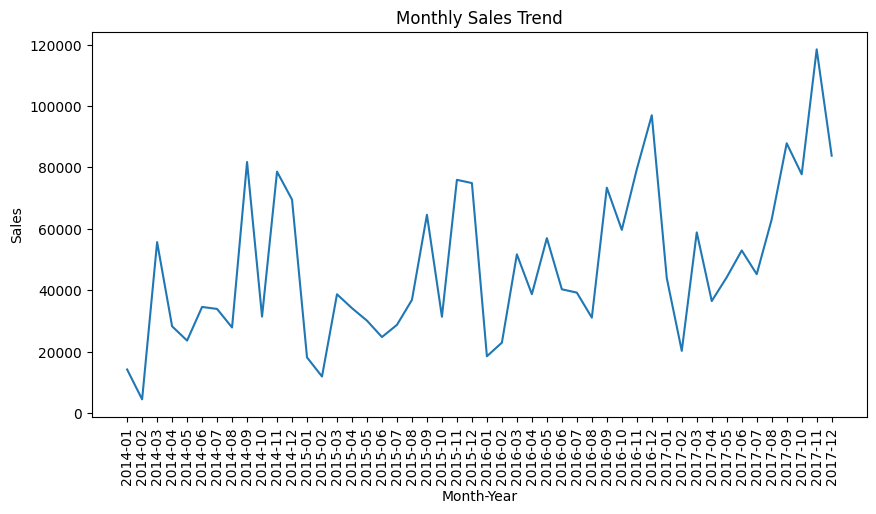

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month_Year'].astype(str), monthly_sales['Sales'])
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")
plt.show()

In [30]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values(by='Sales', ascending=False)

category_sales

,Category,Sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


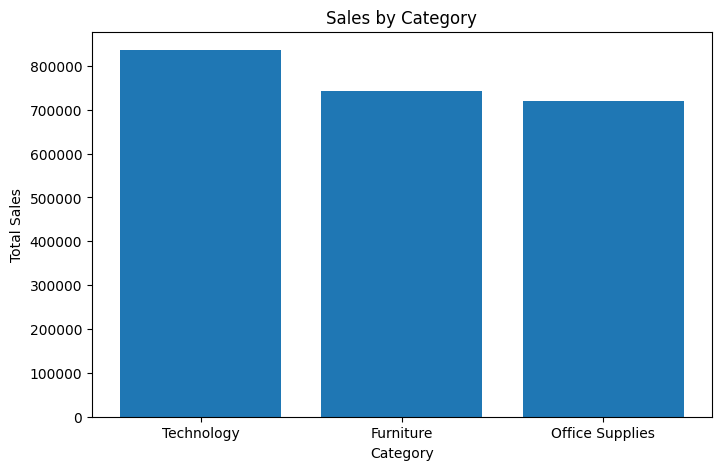

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(category_sales['Category'], category_sales['Sales'])

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [32]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values(by='Sales', ascending=False)

region_sales

,Region,Sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


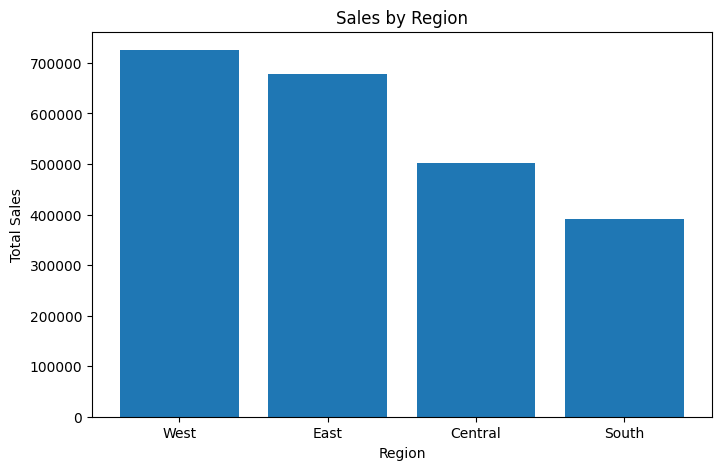

In [33]:
plt.figure(figsize=(8,5))
plt.bar(region_sales['Region'], region_sales['Sales'])

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()


In [34]:
top_products = df.groupby('Product Name')['Sales'].sum().reset_index()
top_products = top_products.sort_values(by='Sales', ascending=False).head(10)

top_products

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


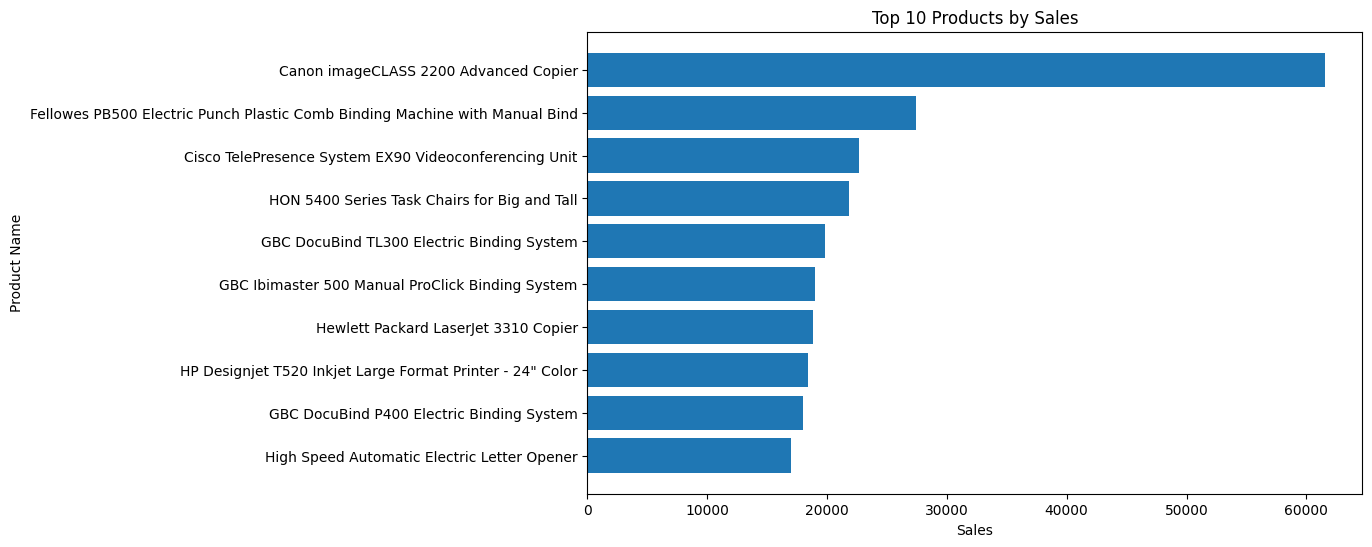

In [35]:
plt.figure(figsize=(10,6))

plt.barh(top_products['Product Name'], top_products['Sales'])

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.show()

In [36]:
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()
segment_sales = segment_sales.sort_values(by='Sales', ascending=False)

segment_sales

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


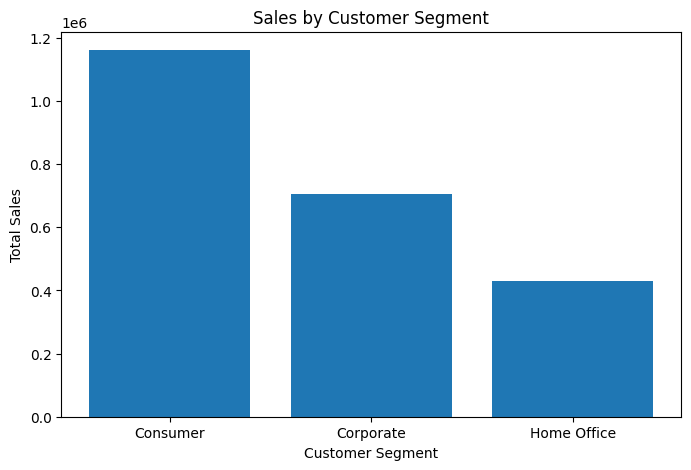

In [37]:
plt.figure(figsize=(8,5))

plt.bar(segment_sales['Segment'], segment_sales['Sales'])

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.show()

In [38]:
profit_category = df.groupby('Category')['Profit'].sum().reset_index()
profit_category = profit_category.sort_values(by='Profit', ascending=False)

profit_category

,Category,Profit
2,Technology,145454.9481
1,Office Supplies,122490.8008
0,Furniture,18451.2728


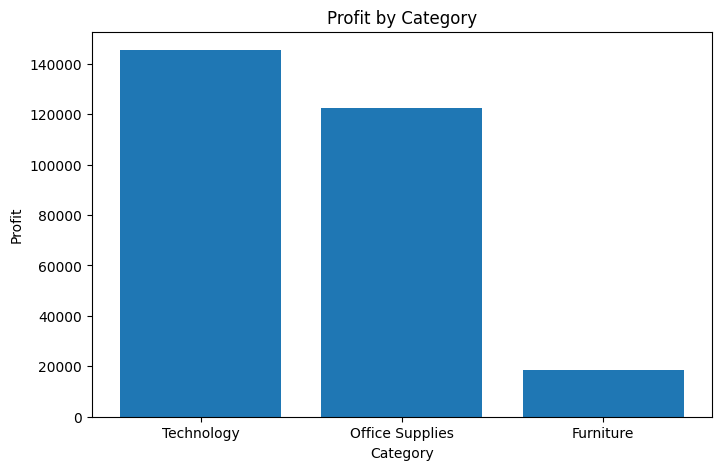

In [39]:
plt.figure(figsize=(8,5))

plt.bar(profit_category['Category'], profit_category['Profit'])

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [40]:
df.to_csv("superstore_clean.csv", index=False)